Resultados del ajuste lineal:
Pendiente (esperada = 4): 3.9976
Intercepto: -1.6712e+01
Constante de Stefan-Boltzmann experimental: 5.8110e-08 W/(m^2 K^4)
Coeficiente de correlación: 0.9998


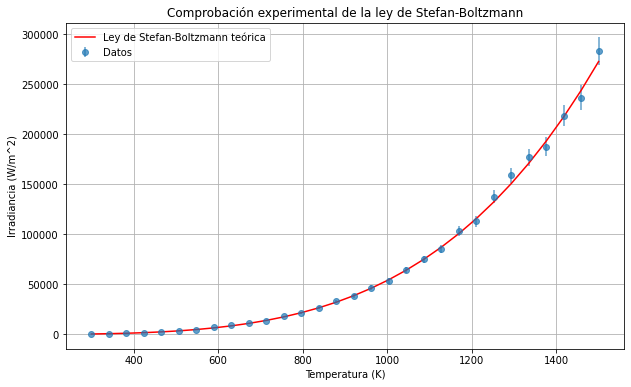

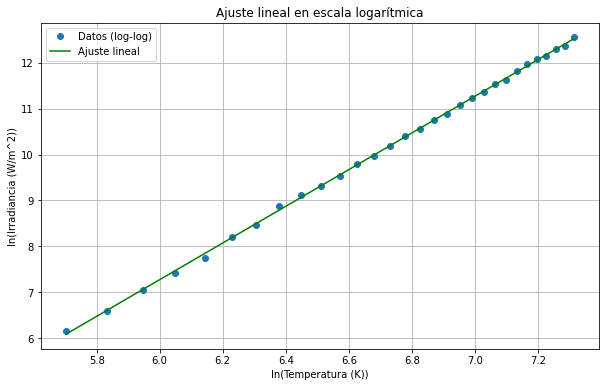

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Constante de Stefan-Boltzmann teórica
sigma_teorica = 5.67e-8  # W/(m^2 K^4)

# Función mediciones con incertidumbre
def simular_irradiancia(temperaturas, emisividad, incertidumbre_relativa):
    irradiancias = emisividad * sigma_teorica * temperaturas**4
    incertidumbre = irradiancias * incertidumbre_relativa
    mediciones = irradiancias + np.random.normal(0, incertidumbre, len(temperaturas))
    return mediciones, incertidumbre

# Configuración de 
emisividad = 0.95
incertidumbre_relativa = 0.05

temperaturas = np.linspace(300, 1500, 30)  # Temperaturas en Kelvin
irradiancias_simuladas, incertidumbres = simular_irradiancia(temperaturas, emisividad, incertidumbre_relativa)

# Ajuste lineal en escala logarítmica
log_temperaturas = np.log(temperaturas)
log_irradiancias = np.log(irradiancias_simuladas)

slope, intercept, r_value, p_value, std_err = linregress(log_temperaturas, log_irradiancias)

# Constante experimental
sigma_experimental = np.exp(intercept) / emisividad

# Resultados
print("Resultados del ajuste lineal:")
print(f"Pendiente (esperada = 4): {slope:.4f}")
print(f"Intercepto: {intercept:.4e}")
print(f"Constante de Stefan-Boltzmann experimental: {sigma_experimental:.4e} W/(m^2 K^4)")
print(f"Coeficiente de correlación: {r_value:.4f}")

# Gráficas
plt.figure(figsize=(10, 6))
plt.errorbar(temperaturas, irradiancias_simuladas, yerr=incertidumbres, fmt='o', label='Datos', alpha=0.7)
plt.plot(temperaturas, emisividad * sigma_teorica * temperaturas**4, label='Ley de Stefan-Boltzmann teórica', color='red')
plt.xlabel("Temperatura (K)")
plt.ylabel("Irradiancia (W/m^2)")
plt.title("Comprobación experimental de la ley de Stefan-Boltzmann")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(log_temperaturas, log_irradiancias, 'o', label='Datos (log-log)')
plt.plot(log_temperaturas, slope * log_temperaturas + intercept, label='Ajuste lineal', color='green')
plt.xlabel("ln(Temperatura (K))")
plt.ylabel("ln(Irradiancia (W/m^2))")
plt.title("Ajuste lineal en escala logarítmica")
plt.legend()
plt.grid()
plt.show()
